In [4]:
"""
1. 신호 받는 뉴런을 10 → 3, 1로 줄였을 때 정확도 변화 그래프.
2. bias 크기를 0.1 ~ 2.0 범위 sweep → SNR vs 정확도 시각화.
3. `RandomForestClassifier`, `SVC(rbf)`로 교체해 성능 비교.
4. confusion matrix 출력 (`sklearn.metrics.confusion_matrix`).
5. (응용) Day 3 BCI 데이터를 trial 평균 전력으로 요약해 같은 디코더로 분류 시도.
"""

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

np.random.seed(0)
n_trials, n_neurons = 100, 50

# TODO: 가상 데이터
#   X: (n_trials, n_neurons), 표준정규
#   y: 절반 0, 절반 1
#   class 1에서만 처음 10개 뉴런에 +1.0 bias
X = np.random.randn(n_trials, n_neurons)
y = np.array([0]*50 + [1]*50)

X[y==1, :10] += 1.0
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X, y, cv=5)
print(f"Accuracy: {scores.mean():.2%} ± {scores.std():.2%}")

Accuracy: 96.00% ± 2.00%


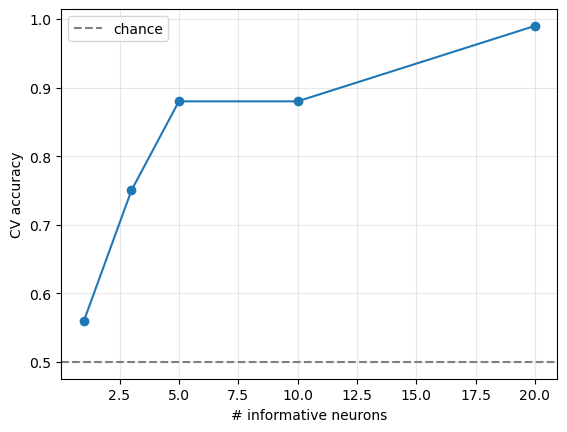

In [11]:
# 1. 신호 받는 뉴런을 10 → 3, 1로 줄였을 때 정확도 변화 그래프.
import matplotlib.pyplot as plt

def make_data(n_signal, bias=1.0, n_trials=100, n_neurons=50, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n_trials, n_neurons))
    y = np.array([0]*(n_trials//2) + [1]*(n_trials//2))
    X[y == 1, :n_signal] += bias
    return X, y

n_signal_list = [1, 3, 5, 10, 20]
accs = []
for n_signal in n_signal_list:
    X, y = make_data(n_signal)
    clf = LogisticRegression(max_iter=1000)
    scores = cross_val_score(clf, X, y, cv=5)
    accs.append(scores.mean())

plt.plot(n_signal_list, accs, 'o-')
plt.xlabel('# informative neurons')
plt.ylabel('CV accuracy')
plt.axhline(0.5, color='gray', linestyle='--', label='chance')
plt.legend(); plt.grid(alpha=0.3); plt.show()


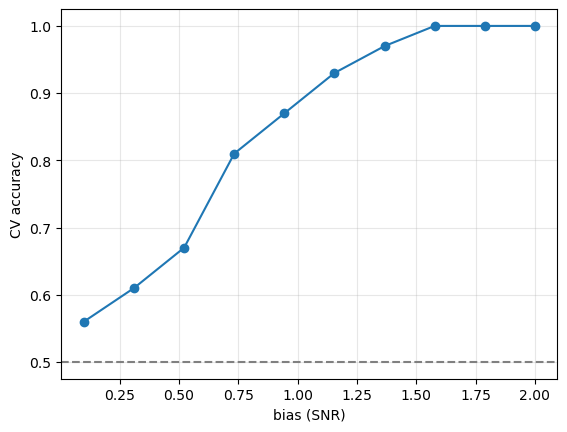

In [12]:
# 2. bias 크기를 0.1 ~ 2.0 범위 sweep → SNR vs 정확도 시각화.

biases = np.linspace(0.1, 2.0, 10)
accs = []
for b in biases:
    X, y = make_data(n_signal=10, bias=b)
    scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5)
    accs.append(scores.mean())

plt.plot(biases, accs, 'o-')
plt.xlabel('bias (SNR)')
plt.ylabel('CV accuracy')
plt.axhline(0.5, color='gray', linestyle='--')
plt.grid(alpha=0.3); plt.show()

In [13]:
# 3. `RandomForestClassifier`, `SVC(rbf)`로 교체해 성능 비교.

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

X, y = make_data(n_signal=10, bias=1.0)

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=0),
    'SVC(rbf)': SVC(kernel='rbf')
}

for name, clf in classifiers.items():
    scores = cross_val_score(clf, X, y, cv=5)
    print(f"{name}: {scores.mean():.2%} ± {scores.std():.2%}")

LogisticRegression: 88.00% ± 6.00%
RandomForest: 90.00% ± 7.07%
SVC(rbf): 92.00% ± 4.00%


[[47  3]
 [ 9 41]]


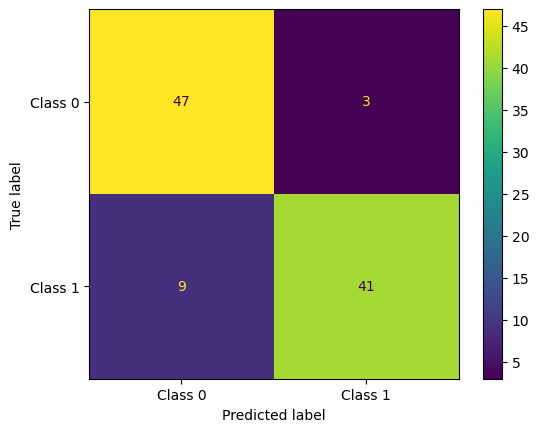

In [14]:
# 4. confusion matrix 출력 (`sklearn.metrics.confusion_matrix`).

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

X, y = make_data(n_signal=10, bias=1.0)
clf = LogisticRegression(max_iter=1000)

# cross_val_predict: CV 폴드별 예측을 모아서 전체 y_pred 반환
y_pred = cross_val_predict(clf, X, y, cv=5)

cm = confusion_matrix(y, y_pred)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1']).plot()
plt.show()

In [18]:
# 5. (응용) Day 3 BCI 데이터를 trial 평균 전력으로 요약해 같은 디코더로 분류 시도.
import mne
from mne.datasets import sample
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 1. 데이터 로드
data_path = sample.data_path()
raw = mne.io.read_raw_fif(
    data_path / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif',
    preload=True)
events = mne.read_events(
    data_path / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw-eve.fif')

# 2. Epochs 만들기 (auditory vs visual만)
event_id = {'auditory': 1, 'visual': 3}
# ↑ 1은 aud/left, 3은 vis/left만 뽑음 (2-class 단순화)
epochs = mne.Epochs(raw, events, event_id, tmin=-0.2, tmax=0.5,
                    baseline=(None, 0), picks='eeg', preload=True)

# 3. Feature: trial별 채널당 분산 (전력 proxy)
X = epochs.get_data().var(axis=2)   # (n_trials, n_channels)
y = epochs.events[:, -1]            # 1 or 3

# 4. 디코딩
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X, y, cv=5)
print(f"Accuracy: {scores.mean():.2%} ± {scores.std():.2%}")

Opening raw data file C:\Users\Hangeulkim\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Not setting metadata
145 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 145 events and 106 original time points ...
0 bad epochs dropped
Accuracy: 48.28% ± 0.00%
